In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.tree import plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
adult = pd.read_csv('/content/drive/MyDrive/CSE422/adult income dataset.csv')
adult.head(3)

,Age,Workclass,Final Weight,Education,Education Number of Years,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [4]:
adult.shape

(48842, 15)

CHECK FOR MISSING VALUES

In [5]:
adult.replace('?', np.nan, inplace=True)
adult.isnull().sum()

,0
Age,0
Workclass,2799
Final Weight,0
Education,0
Education Number of Years,0
Marital-status,0
Occupation,2809
Relationship,0
Race,0
Sex,0


IMPUTATIION FOR MISSING VALUES

In [6]:
cols_to_fix = ['Workclass', 'Occupation', 'Native-country']


imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

adult[cols_to_fix] = imputer.fit_transform(adult[cols_to_fix])

In [7]:
adult

,Age,Workclass,Final Weight,Education,Education Number of Years,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,Private,321403,HS-grad,9,Widowed,Prof-specialty,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


In [8]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        48842 non-null  int64 
 1   Workclass                  48842 non-null  object
 2   Final Weight               48842 non-null  int64 
 3   Education                  48842 non-null  object
 4   Education Number of Years  48842 non-null  int64 
 5   Marital-status             48842 non-null  object
 6   Occupation                 48842 non-null  object
 7   Relationship               48842 non-null  object
 8   Race                       48842 non-null  object
 9   Sex                        48842 non-null  object
 10  Capital-gain               48842 non-null  int64 
 11  Capital-loss               48842 non-null  int64 
 12  Hours-per-week             48842 non-null  int64 
 13  Native-country             48842 non-null  object
 14  target

ENCODING

In [9]:
if 'target' in adult.columns:
    le = LabelEncoder()
    adult['target_encoded'] = le.fit_transform(adult['target'])
    print("Target encoded. Unique values:", adult['target_encoded'].unique())

categorical_cols = ['Sex', 'Relationship', 'Occupation', 'Workclass', 'Native-country', 'Marital-status', 'Race']

existing_cat_cols = []
for col in categorical_cols :
  if col in adult.columns :
    existing_cat_cols.append(col)

adult = pd.get_dummies(adult, columns=existing_cat_cols, drop_first=True)

print("Columns after One-Hot Encoding:", adult.columns)
adult.head()

Target encoded. Unique values: [0 1]
Columns after One-Hot Encoding: Index(['Age', 'Final Weight', 'Education', 'Education Number of Years',
       'Capital-gain', 'Capital-loss', 'Hours-per-week', 'target',
       'target_encoded', 'Sex_Male', 'Relationship_Not-in-family',
       'Relationship_Other-relative', 'Relationship_Own-child',
       'Relationship_Unmarried', 'Relationship_Wife',
       'Occupation_Armed-Forces', 'Occupation_Craft-repair',
       'Occupation_Exec-managerial', 'Occupation_Farming-fishing',
       'Occupation_Handlers-cleaners', 'Occupation_Machine-op-inspct',
       'Occupation_Other-service', 'Occupation_Priv-house-serv',
       'Occupation_Prof-specialty', 'Occupation_Protective-serv',
       'Occupation_Sales', 'Occupation_Tech-support',
       'Occupation_Transport-moving', 'Workclass_Local-gov',
       'Workclass_Never-worked', 'Workclass_Private', 'Workclass_Self-emp-inc',
       'Workclass_Self-emp-not-inc', 'Workclass_State-gov',
       'Workclass_With

,Age,Final Weight,Education,Education Number of Years,Capital-gain,Capital-loss,Hours-per-week,target,target_encoded,Sex_Male,...,Marital-status_Married-AF-spouse,Marital-status_Married-civ-spouse,Marital-status_Married-spouse-absent,Marital-status_Never-married,Marital-status_Separated,Marital-status_Widowed,Race_Asian-Pac-Islander,Race_Black,Race_Other,Race_White
0,39,77516,Bachelors,13,2174,0,40,<=50K,0,True,...,False,False,False,True,False,False,False,False,False,True
1,50,83311,Bachelors,13,0,0,13,<=50K,0,True,...,False,True,False,False,False,False,False,False,False,True
2,38,215646,HS-grad,9,0,0,40,<=50K,0,True,...,False,False,False,False,False,False,False,False,False,True
3,53,234721,11th,7,0,0,40,<=50K,0,True,...,False,True,False,False,False,False,False,True,False,False
4,28,338409,Bachelors,13,0,0,40,<=50K,0,False,...,False,True,False,False,False,False,False,True,False,False


In [10]:
if 'Education' in adult.columns :
  adult=adult.drop('Education', axis=1)
  print("Dropped redundant 'Education' column.")

Dropped redundant 'Education' column.


In [11]:
numeric_cols = adult.select_dtypes(include=np.number).columns
display(adult[numeric_cols].describe())

,Age,Final Weight,Education Number of Years,Capital-gain,Capital-loss,Hours-per-week,target_encoded
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382,0.239282
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444,0.426649
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [12]:
adult_eda = adult.copy()

### Histograms of Key Numerical Features

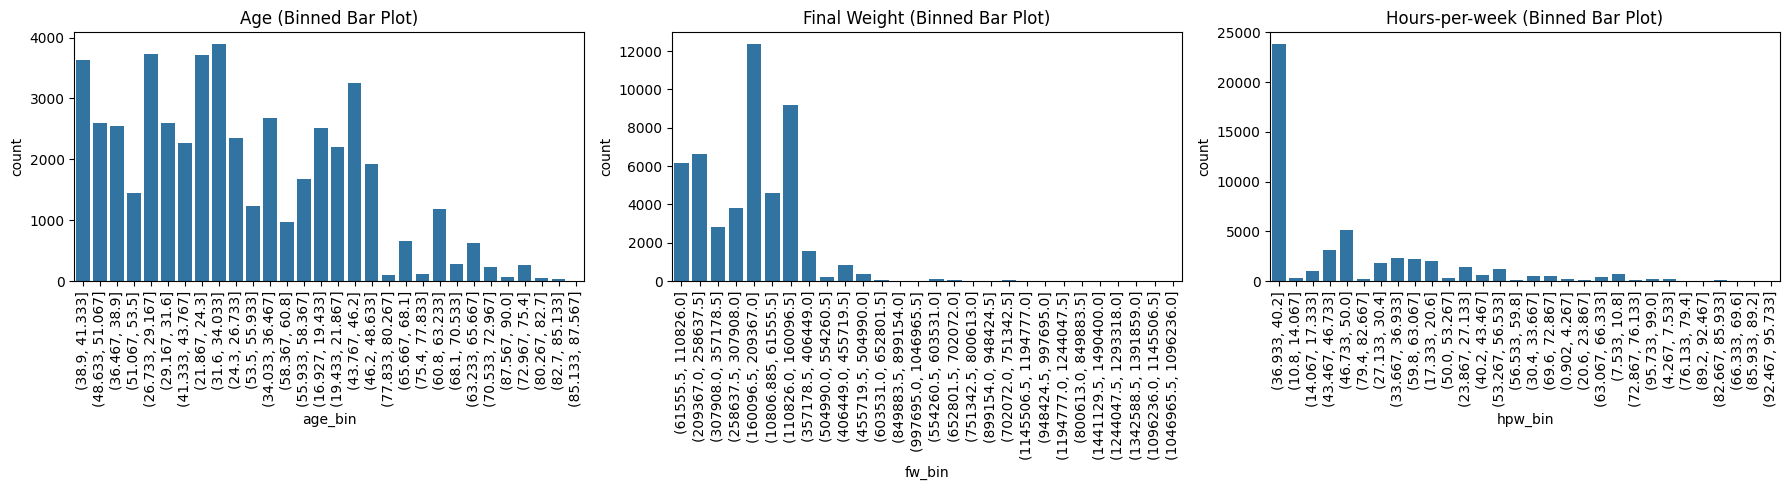

In [13]:
adult_eda['age_bin'] = pd.cut(adult_eda['Age'], bins=30).astype(str)
adult_eda['fw_bin'] = pd.cut(adult_eda['Final Weight'], bins=30).astype(str)
adult_eda['hpw_bin'] = pd.cut(adult_eda['Hours-per-week'], bins=30).astype(str)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='age_bin', data=adult_eda, ax=axes[0])
axes[0].set_title('Age (Binned Bar Plot)')
axes[0].tick_params(axis='x', rotation=90)

sns.countplot(x='fw_bin', data=adult_eda, ax=axes[1])
axes[1].set_title('Final Weight (Binned Bar Plot)')
axes[1].tick_params(axis='x', rotation=90)

sns.countplot(x='hpw_bin', data=adult_eda, ax=axes[2])
axes[2].set_title('Hours-per-week (Binned Bar Plot)')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

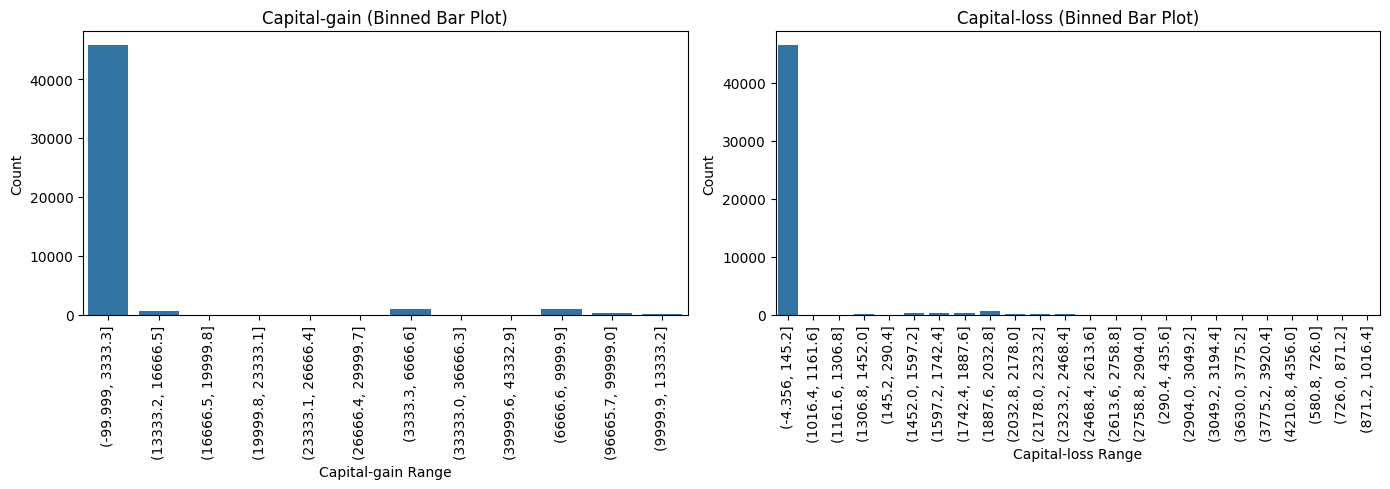

In [14]:
adult_eda['cg_bin'] = pd.cut(adult_eda['Capital-gain'], bins=30).astype(str)
adult_eda['cl_bin'] = pd.cut(adult_eda['Capital-loss'], bins=30).astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Capital-gain bar plot
cg_counts = adult_eda['cg_bin'].value_counts().sort_index()
sns.barplot(x=cg_counts.index.astype(str), y=cg_counts.values, ax=axes[0])
axes[0].set_title('Capital-gain (Binned Bar Plot)')
axes[0].set_xlabel('Capital-gain Range')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)

# Capital-loss bar plot
cl_counts = adult_eda['cl_bin'].value_counts().sort_index()
sns.barplot(x=cl_counts.index.astype(str), y=cl_counts.values, ax=axes[1])
axes[1].set_title('Capital-loss (Binned Bar Plot)')
axes[1].set_xlabel('Capital-loss Range')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


CHECK FOR PAIRWISE CORELATION

In [15]:
numeric_adult = adult.select_dtypes(include=[np.number])
adult_corr = numeric_adult.corr()
adult_corr


,Age,Final Weight,Education Number of Years,Capital-gain,Capital-loss,Hours-per-week,target_encoded
Age,1.000000,-0.076628,0.030940,0.077229,0.056944,0.071558,0.230369
Final Weight,-0.076628,1.000000,-0.038761,-0.003706,-0.004366,-0.013519,-0.006339
Education Number of Years,0.030940,-0.038761,1.000000,0.125146,0.080972,0.143689,0.332613
Capital-gain,0.077229,-0.003706,0.125146,1.000000,-0.031441,0.082157,0.223013
Capital-loss,0.056944,-0.004366,0.080972,-0.031441,1.000000,0.054467,0.147554
Hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,1.000000,0.227687
target_encoded,0.230369,-0.006339,0.332613,0.223013,0.147554,0.227687,1.000000


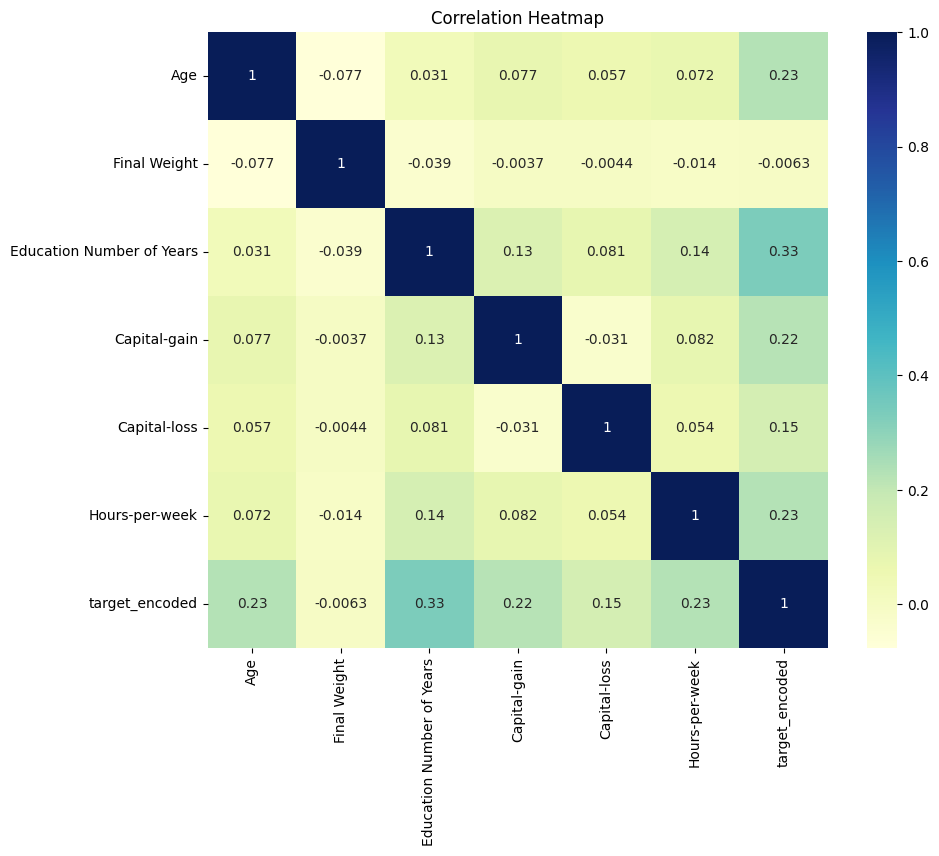

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(adult_corr, annot=True, cmap='YlGnBu')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
X = adult.drop(['target', 'target_encoded'], axis=1, errors='ignore')

if 'target_encoded' in adult.columns:
  y = adult['target_encoded']
else :
   y = []

cols_to_scale = ['Age', 'Final Weight', 'Education Number of Years',
                 'Capital-gain', 'Capital-loss', 'Hours-per-week']

TEST FOR IMBALANCED DATASET


Distribution of Target Variable:
target_encoded
0    37155
1    11687
Name: count, dtype: int64


/tmp/ipython-input-1935623786.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')


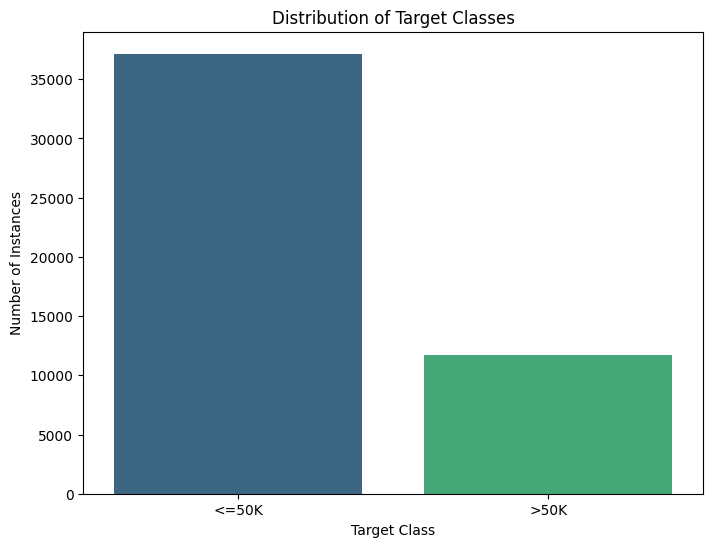


Classes do not have an equal number of instances (imbalanced dataset).
Ratio of majority to minority class: 3.18:1


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

target_counts = y.value_counts()

print("Distribution of Target Variable:")
print(target_counts)

plt.figure(figsize=(8, 6))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribution of Target Classes')
plt.xlabel('Target Class')
plt.ylabel('Number of Instances')

plt.xticks(ticks=[0, 1], labels=['<=50K', '>50K'])
plt.show()

if target_counts.nunique() == 1:
    print("\nAll unique classes have an equal number of instances (balanced dataset).")
else:
    print("\nClasses do not have an equal number of instances (imbalanced dataset).")
    print(f"Ratio of majority to minority class: {target_counts.max() / target_counts.min():.2f}:1")

STANDARDSCALER

In [19]:
scaler1 = StandardScaler()

existing_cols1 = [col for col in cols_to_scale if col in X.columns]
X[existing_cols1] = scaler1.fit_transform(X[existing_cols1])

print("Scaling complete. First 5 rows of Age (Scaled):")
print(X['Age'].head())

Scaling complete. First 5 rows of Age (Scaled):
0    0.025996
1    0.828308
2   -0.046942
3    1.047121
4   -0.776316
Name: Age, dtype: float64


In [20]:
# scaler2 = MinMaxScaler()

# existing_cols2 = [col for col in cols_to_scale if col in X.columns]
# X[existing_cols2] = scaler2.fit_transform(X[existing_cols2])

# print("Scaling complete. First 5 rows of Age (Scaled):")
# print(X['Age'].head())

SPLITTING FOR TRAINING AND TESTING

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (39073, 82)
Testing shape: (9769, 82)


TRAINING THE MODELS

In [22]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)
clf.fit(X_train, y_train)
y_pred_clf = clf.predict(X_test)
accuracy_clf = metrics.accuracy_score(y_test, y_pred_clf)
print(f"Accuracy: {accuracy_clf:.2f}")
print("\nConfusion Matrix:")
cm_clf  = confusion_matrix(y_test, y_pred_clf)
print(cm_clf)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_clf))

Accuracy: 0.84

Confusion Matrix:
[[7041  389]
 [1130 1209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      7430
           1       0.76      0.52      0.61      2339

    accuracy                           0.84      9769
   macro avg       0.81      0.73      0.76      9769
weighted avg       0.84      0.84      0.83      9769



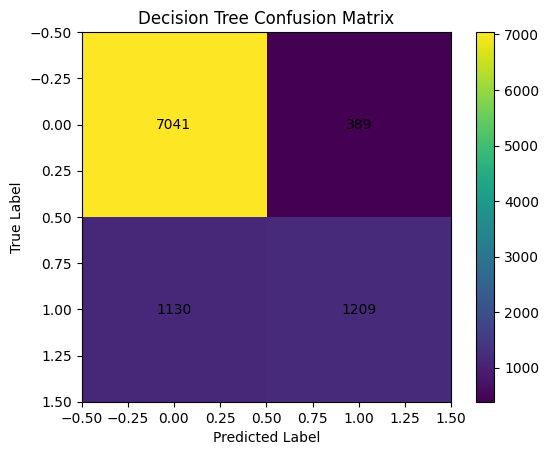

In [23]:
plt.figure()
plt.imshow(cm_clf)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm_clf.shape[0]):
    for j in range(cm_clf.shape[1]):
        plt.text(j, i, cm_clf[i, j], ha="center", va="center")

plt.show()

In [24]:
lr = LogisticRegression(solver='liblinear', random_state=0)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
accuracy_lr = lr.score(X_test, y_test)
print(f"Accuracy: {accuracy_lr:.2f}")
print("\nConfusion Matrix:")
cm_lr  = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.85

Confusion Matrix:
[[6911  519]
 [ 924 1415]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      7430
           1       0.73      0.60      0.66      2339

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.78      9769
weighted avg       0.85      0.85      0.85      9769



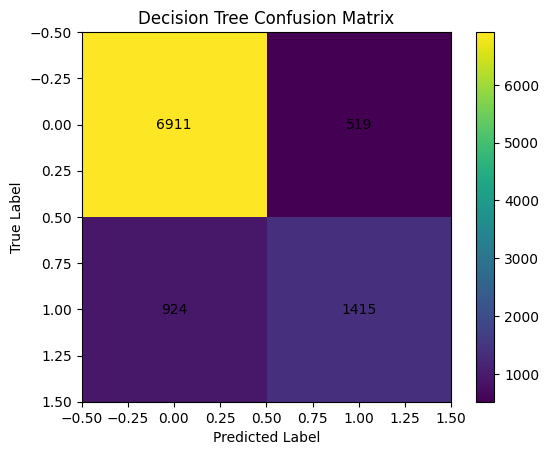

In [25]:
plt.figure()
plt.imshow(cm_lr)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, cm_lr[i, j], ha="center", va="center")

plt.show()

In [26]:
X_train_nn = X_train
y_train_nn = y_train
X_test_nn = X_test
y_test_nn = y_test

In [27]:
nn = Sequential([
    Flatten(input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
nn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [29]:
nn.fit(X_train_nn, y_train_nn, epochs=10, validation_split=0.2)

Epoch 1/10
977/977 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8328 - loss: 0.3496 - val_accuracy: 0.8521 - val_loss: 0.3180
Epoch 2/10
977/977 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8561 - loss: 0.3074 - val_accuracy: 0.8569 - val_loss: 0.3128
Epoch 3/10
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8575 - loss: 0.3037 - val_accuracy: 0.8580 - val_loss: 0.3075
Epoch 4/10
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8618 - loss: 0.2990 - val_accuracy: 0.8557 - val_loss: 0.3097
Epoch 5/10
977/977 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8631 - loss: 0.2920 - val_accuracy: 0.8563 - val_loss: 0.3098
Epoch 6/10
977/977 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8659 - loss: 0.2890 - val_accuracy: 0.8569 - val_loss: 0.3097
Epoch 7/10
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8640 - loss: 0.2916 - val_accuracy: 0.8540 - val_loss: 0.3121
Epoch 8/10
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8671 - loss: 0.2880 - val_accuracy: 0.

In [30]:
X_test_nn = X_test
y_test_nn = y_test
test_loss, test_accuracy = nn.evaluate(X_test_nn, y_test_nn)
print(f"Accuracy: {test_accuracy:.2f}")

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8581 - loss: 0.3119
Accuracy: 0.86


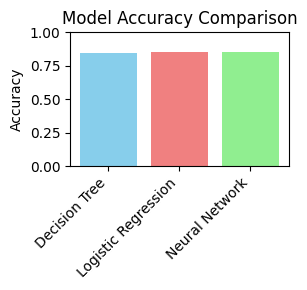

In [31]:


accuracy_scores = {
    'Decision Tree': accuracy_clf,
    'Logistic Regression': accuracy_lr,
    'Neural Network': test_accuracy
}


models = list(accuracy_scores.keys())
scores = list(accuracy_scores.values())

plt.figure(figsize=(3, 3))
plt.bar(models, scores, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'purple'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [32]:


y_pred_clf_proba = clf.predict_proba(X_test)[:, 1]

y_pred_lr_proba = lr.predict_proba(X_test)[:, 1]

y_pred_nn_proba = nn.predict(X_test_nn)[:, 1]

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


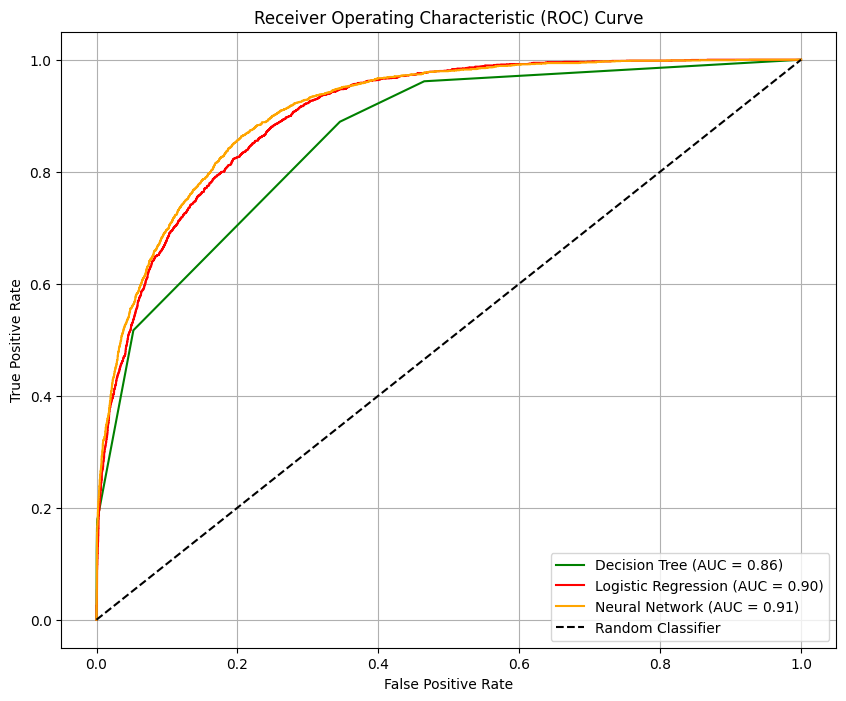

In [33]:

fpr_clf, tpr_clf, _ = roc_curve(y_test, y_pred_clf_proba)
auc_clf = auc(fpr_clf, tpr_clf)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_proba)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_nn_proba)
auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(10, 8))
plt.plot(fpr_clf, tpr_clf, label=f'Decision Tree (AUC = {auc_clf:.2f})', color='green')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', color='red')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})', color='orange')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Reasoning**:
The subtask is to import KMeans and silhouette_score. This code block will perform those imports.



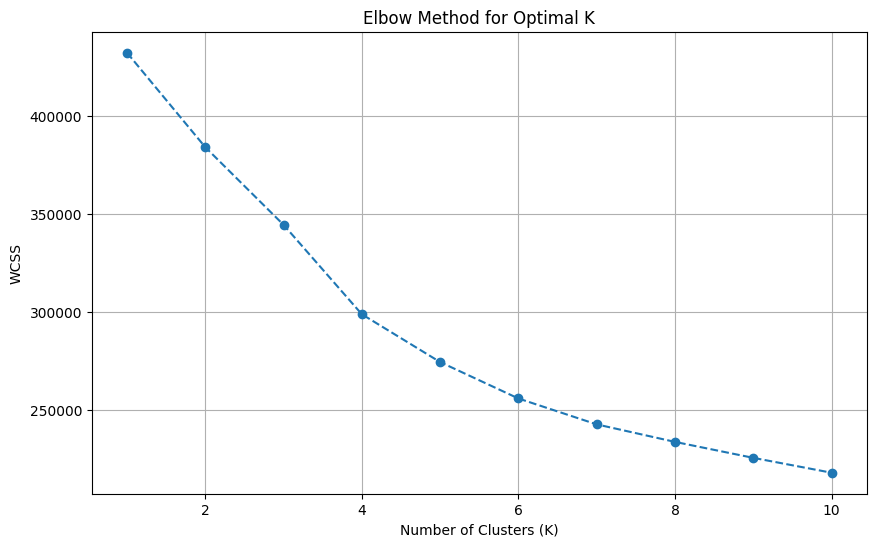

In [34]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [35]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X)
clusters = kmeans.predict(X)

print("KMeans clustering applied successfully.")
print(f"First 5 cluster labels: {clusters[:5]}")

KMeans clustering applied successfully.
First 5 cluster labels: [2 2 1 2 1]


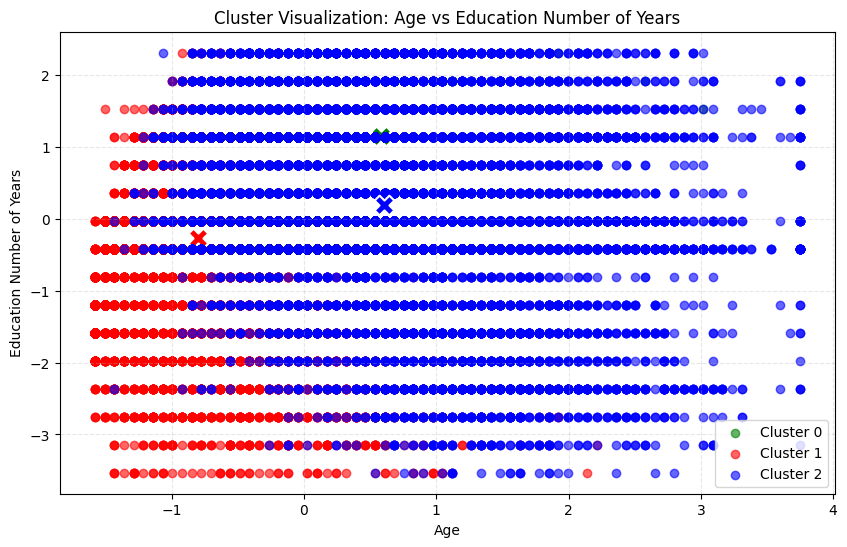

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_cluster1(km, df, x_col, y_col, cluster_num):
    """
    km: Saved KMeans model
    df: Dataframe containing features and the 'Group_clutter' column
    x_col: Name of column for X-axis (e.g., 'Age')
    y_col: Name of column for Y-axis (e.g., 'Education Number of Years')
    cluster_num: Number of clusters to visualize
    """
    if cluster_num > 6:
        print("Cluster number should be less than 6, make your own plot method to fit more")
        return

    color = ['green', 'red', 'blue', 'purple', 'black', 'yellow']

    # Find the index of the columns in the dataframe to match with km.cluster_centers_
    # This assumes the dataframe columns match the order used during kmeans.fit(X)
    x_idx = df.columns.get_loc(x_col)
    y_idx = df.columns.get_loc(y_col)

    plt.figure(figsize=(10, 6))

    for i in range(cluster_num):
        # 1. Plot the data points for this cluster
        subset = df[df.Group_clutter == i]
        plt.scatter(subset[x_col], subset[y_col], color=color[i], alpha=0.6, label=f'Cluster {i}')

        # 2. Plot the Centroid (using the correct column indices)
        # We use x_idx and y_idx instead of hardcoded 0 and 1
        plt.scatter(km.cluster_centers_[i, x_idx], km.cluster_centers_[i, y_idx],
                    color=color[i], s=200, marker='X', edgecolors='white', linewidth=1.5)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'Cluster Visualization: {x_col} vs {y_col}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# --- How to use it with your data ---

# 1. Setup your DataFrame (assuming X is your data array)
# Replace these with your actual column names from the heatmap
cols = ['Age', 'Final Weight', 'Education Number of Years', 'Capital-gain', 'Capital-loss', 'Hours-per-week']
df_plot = pd.DataFrame(X, columns=cols)
df_plot['Group_clutter'] = clusters  # Add your predicted labels

# 2. Call the function
# Example: Plotting 'Age' vs 'Education Number of Years'
plot_cluster1(kmeans, df_plot, 'Age', 'Education Number of Years', 3)